In [11]:
import os
import time
import logging
from collections import Counter

import pandas as pd
import numpy as np
from dotenv import load_dotenv
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import AutoTokenizer, AutoModel
import torch
import tiktoken
from tabulate import tabulate

# OpenAI client
from openai import OpenAI
# Gemini client
import google.generativeai as genai

# LangGraph / LangChain runnables
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableLambda

In [2]:
# Logging
# -------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("LangGraphPipeline")

In [3]:
# -------------------------
# Config & paths
# -------------------------
load_dotenv()  # loads keys from .env in project root
OPENAI_KEY = os.getenv("OPENAI_API_KEY")
GOOGLE_KEY = os.getenv("GOOGLE_API_KEY")

INPUT_CSV = "data/preprocessed_dataset.csv"
OUT_PER_ROW = "data/final_langgraph_agent_results_token.csv"
OUT_MATRIX = "data/decision_matrix_summary.csv"

if not os.path.exists(INPUT_CSV):
    logger.error(f"Input file not found: {INPUT_CSV}")
    raise SystemExit("Place preprocessed_dataset.csv under data/ and re-run.")

In [4]:
# -------------------------
# Load dataset
# -------------------------
df_input = pd.read_csv(INPUT_CSV, encoding="utf-8")
logger.info(f"Loaded {len(df_input)} rows from {INPUT_CSV}")

# required columns check
required_cols = {"input_text", "target_language", "human_translated_text"}
if not required_cols.issubset(set(df_input.columns)):
    missing = required_cols - set(df_input.columns)
    logger.error(f"Input CSV missing required columns: {missing}")
    raise SystemExit("Fix CSV columns and re-run.")

2025-11-04 17:09:46,788 | INFO | Loaded 673 rows from data/preprocessed_dataset.csv


In [5]:
# -------------------------
# Initialize API clients (if keys present)
# -------------------------
openai_client = OpenAI(api_key=OPENAI_KEY) if OPENAI_KEY else None
if GOOGLE_KEY:
    genai.configure(api_key=GOOGLE_KEY)
    try:
        google_model = genai.GenerativeModel("gemini-2.5-flash")
    except Exception:
        google_model = None
else:
    google_model = None

In [6]:
# -------------------------
# Utilities: BLEU smoother, embeddings, cosine, token counting
# -------------------------
smoother = SmoothingFunction().method1

EMB_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
logger.info(f"Loading embedding model '{EMB_MODEL}' (one-time download)...")
tokenizer_emb = AutoTokenizer.from_pretrained(EMB_MODEL)
model_emb = AutoModel.from_pretrained(EMB_MODEL)
model_emb.eval()
if torch.cuda.is_available():
    model_emb = model_emb.to("cuda")
logger.info("Embedding model ready.")

def embed_text(text: str):
    if not isinstance(text, str) or text.strip() == "":
        return np.zeros(model_emb.config.hidden_size)
    inputs = tokenizer_emb(text, return_tensors="pt", truncation=True, max_length=512)
    if torch.cuda.is_available():
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
    with torch.no_grad():
        out = model_emb(**inputs)
        token_embeddings = out.last_hidden_state
        attention_mask = inputs.get("attention_mask")
        if attention_mask is None:
            pooled = token_embeddings.mean(dim=1)
        else:
            mask = attention_mask.unsqueeze(-1)
            summed = (token_embeddings * mask).sum(dim=1)
            denom = mask.sum(dim=1).clamp(min=1e-9)
            pooled = summed / denom
        emb = pooled[0].cpu().numpy()
    return emb

def cosine_sim(a: np.ndarray, b: np.ndarray):
    if a is None or b is None:
        return 0.0
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

# Token encoder best-effort - gpt-5-nano , gpt-4o-mini
def get_token_encoder(model_name="gpt-5-nano"):
    try:
        return tiktoken.encoding_for_model(model_name)
    except Exception:
        return tiktoken.get_encoding("gpt2")

token_encoder = get_token_encoder()

def count_tokens(text: str):
    if not isinstance(text, str) or text.strip() == "":
        return 0
    try:
        return len(token_encoder.encode(text))
    except Exception:
        return len(text.split())

2025-11-04 17:16:21,884 | INFO | Loading embedding model 'sentence-transformers/all-MiniLM-L6-v2' (one-time download)...
2025-11-04 17:16:24,554 | INFO | Embedding model ready.


In [7]:
# -------------------------
# Tone & Domain detection heuristics
# -------------------------
formal_words = {"please", "kindly", "regards", "sincerely", "attached", "review"}
polite_words = {"please", "thank", "thanks", "appreciate"}
technical_words = {"algorithm", "dataset", "model", "research", "experiment"}
slang_words = {"lol", "brb", "u ", "ur ", "omg", "ya "}

def detect_tone_domain(text: str):
    t = str(text).strip()
    t_lower = t.lower()
    # Domain
    if any(w in t_lower for w in ["attach", "attached", "invoice", "proposal", "resume", "cv", "document", "review"]):
        domain = "Business"
    elif any(w in t_lower for w in ["story", "novel", "poem", "song", "creative"]):
        domain = "Creative"
    elif any(w in t_lower for w in ["research", "paper", "dataset", "experiment", "results"]):
        domain = "Research"
    elif any(w in t_lower for w in ["dear", "regards", "sincerely", "cc:"]):
        domain = "Email"
    elif any(w in t_lower for w in slang_words):
        domain = "Chat"
    else:
        domain = "General"
    # Tone
    tone = "Neutral"
    if any(w in t_lower for w in formal_words):
        tone = "Formal"
    if any(w in t_lower for w in polite_words):
        tone = "Polite"
    if any(w in t_lower for w in technical_words):
        tone = "Technical"
    if any(w in t_lower for w in slang_words):
        tone = "Slang/Code-Mixed"
    if len(t.split()) <= 3:
        tone = "Short/Simple"
    return tone, domain

In [8]:
# -------------------------
# Translation helpers (per-row)
# -------------------------
def translate_openai(text: str, target_lang: str):
    if not openai_client:
        return "", 0
    try:
        resp = openai_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": f"Translate the following text to {target_lang}."},
                {"role": "user", "content": text}
            ],
            temperature=0.2,
            max_tokens=1500
        )
        translated = resp.choices[0].message.content.strip()
        tokens = getattr(resp.usage, "total_tokens", None) or (count_tokens(text) + count_tokens(translated))
        return translated, int(tokens)
    except Exception as e:
        logger.warning(f"OpenAI translation error: {e}")
        return "", 0

def translate_gemini(text: str, target_lang: str):
    if not google_model:
        return "", 0
    try:
        prompt = f"Translate this text into {target_lang}:\n\n{text}"
        resp = google_model.generate_content(prompt)
        translated = resp.text.strip() if hasattr(resp, "text") else str(resp).strip()
        tokens = count_tokens(text) + count_tokens(translated)  # approximate
        return translated, int(tokens)
    except Exception as e:
        logger.warning(f"Gemini translation error: {e}")
        return "", 0

In [9]:
# -------------------------
# Graph nodes: each node processes the entire dataset in batch
# -------------------------
def ToneDomainAgent(state: dict):
    """state expected: {'df': DataFrame (copied or path)}"""
    df = state.get("df")
    rows = []
    for _, r in df.iterrows():
        tone, domain = detect_tone_domain(r["input_text"])
        row = r.copy()
        row["tone"] = tone
        row["domain"] = domain
        rows.append(row)
    state["df_toned"] = pd.DataFrame(rows)
    return state

def TranslationAgent(state: dict):
    """Translates all rows in state['df_toned'] using available APIs."""
    df = state.get("df_toned")
    out_rows = []
    for _, r in df.iterrows():
        text = str(r["input_text"])
        lang = str(r["target_language"]).strip().lower()
        o_trans, o_tokens = translate_openai(text, lang) if openai_client else ("", 0)
        g_trans, g_tokens = translate_gemini(text, lang) if google_model else ("", 0)
        new = r.to_dict()
        new.update({
            "OpenAI_Trans": o_trans,
            "OpenAI_Tokens": o_tokens,
            "Gemini_Trans": g_trans,
            "Gemini_Tokens": g_tokens
        })
        out_rows.append(new)
        # polite pause
        time.sleep(0.3)
    state["df_translated"] = pd.DataFrame(out_rows)
    return state

def EvaluationAgent(state: dict):
    """Compute BLEU, cosine, avg metric per model for whole df_translated"""
    df = state.get("df_translated")
    rows = []
    for _, r in df.iterrows():
        ref = str(r.get("human_translated_text") or r.get("input_text") or "")
        o_t = str(r.get("OpenAI_Trans") or "")
        g_t = str(r.get("Gemini_Trans") or "")
        try:
            bleu_o = sentence_bleu([ref.split()], o_t.split(), smoothing_function=smoother) if o_t else 0.0
        except Exception:
            bleu_o = 0.0
        try:
            bleu_g = sentence_bleu([ref.split()], g_t.split(), smoothing_function=smoother) if g_t else 0.0
        except Exception:
            bleu_g = 0.0
        emb_ref = embed_text(ref if ref.strip() != "" else r.get("input_text", ""))
        emb_o = embed_text(o_t)
        emb_g = embed_text(g_t)
        cos_o = cosine_sim(emb_ref, emb_o)
        cos_g = cosine_sim(emb_ref, emb_g)
        avg_o = (bleu_o + cos_o) / 2.0
        avg_g = (bleu_g + cos_g) / 2.0
        new = r.to_dict()
        new.update({
            "BLEU_OpenAI": round(bleu_o, 4),
            "BLEU_Gemini": round(bleu_g, 4),
            "Cosine_OpenAI": round(cos_o, 4),
            "Cosine_Gemini": round(cos_g, 4),
            "AvgMetric_OpenAI": round(avg_o, 4),
            "AvgMetric_Gemini": round(avg_g, 4)
        })
        rows.append(new)
    state["df_evaluated"] = pd.DataFrame(rows)
    return state

def DecisionAgent(state: dict):
    """Decide Best model and Classification per row. Also store Best_Tokens."""
    df = state.get("df_evaluated")
    rows = []
    for _, r in df.iterrows():
        avg_o = r.get("AvgMetric_OpenAI", 0.0)
        avg_g = r.get("AvgMetric_Gemini", 0.0)
        if avg_o >= avg_g:
            best = "OpenAI"
            best_score = avg_o
            best_tokens = int(r.get("OpenAI_Tokens", 0) or 0)
        else:
            best = "Gemini"
            best_score = avg_g
            best_tokens = int(r.get("Gemini_Tokens", 0) or 0)
        acc_pct = round(best_score * 100, 2)
        classification = "Yes" if acc_pct >= 85.0 else "No"
        new = r.copy().to_dict()
        new.update({
            "Best": best,
            "Best_Tokens": best_tokens,
            "Accuracy(%)": acc_pct,
            "Classification": classification
        })
        rows.append(new)
    state["df_decided"] = pd.DataFrame(rows)
    return state

def SaveAgent(state: dict):
    """Save final per-row CSV and build decision matrix grouped by (tone, domain)."""
    df_final = state.get("df_decided")
    os.makedirs("data", exist_ok=True)
    df_final.to_csv(OUT_PER_ROW, index=False, encoding="utf-8-sig")
    # Build decision matrix
    matrix_rows = []
    grouped = df_final.groupby(["tone", "domain"])
    for (tone, domain), grp in grouped:
        yes_grp = grp[grp["Classification"] == "Yes"]
        counts = yes_grp["Best"].value_counts()
        if counts.empty:
            avg_scores = grp.groupby("Best")["Accuracy(%)"].mean().dropna()
            if not avg_scores.empty:
                chosen = avg_scores.idxmax()
                chosen_acc = round(avg_scores.max(), 2)
                yes_count = int(grp[(grp["Best"] == chosen) & (grp["Classification"] == "Yes")].shape[0])
            else:
                chosen = "None"
                chosen_acc = 0.0
                yes_count = 0
        else:
            chosen = counts.idxmax()
            chosen_acc = round(grp[grp["Best"] == chosen]["Accuracy(%)"].mean(), 2) if chosen in grp["Best"].values else 0.0
            yes_count = int(counts.get(chosen, 0))
        matrix_rows.append({
            "Tone": tone,
            "Domain": domain,
            "Best_Tool": chosen,
            "Yes_Count": yes_count,
            "Avg_Accuracy(%)": chosen_acc
        })
    matrix_df = pd.DataFrame(matrix_rows).sort_values(["Tone", "Domain"])
    matrix_df.to_csv(OUT_MATRIX, index=False, encoding="utf-8-sig")
    state["df_final"] = df_final
    state["matrix_df"] = matrix_df
    return state

In [13]:
# -------------------------
# Build StateGraph and nodes (single graph for whole dataset)
# -------------------------
graph = StateGraph(dict)
graph.add_node("ToneDomainAgent", RunnableLambda(ToneDomainAgent))
graph.add_node("TranslationAgent", RunnableLambda(TranslationAgent))
graph.add_node("EvaluationAgent", RunnableLambda(EvaluationAgent))
graph.add_node("DecisionAgent", RunnableLambda(DecisionAgent))
graph.add_node("SaveAgent", RunnableLambda(SaveAgent))

graph.add_edge(START, "ToneDomainAgent")          #Entry point
graph.add_edge("ToneDomainAgent", "TranslationAgent")
graph.add_edge("TranslationAgent", "EvaluationAgent")
graph.add_edge("EvaluationAgent", "DecisionAgent")
graph.add_edge("DecisionAgent", "SaveAgent")
graph.add_edge("SaveAgent", END) # Exit point

app = graph.compile()


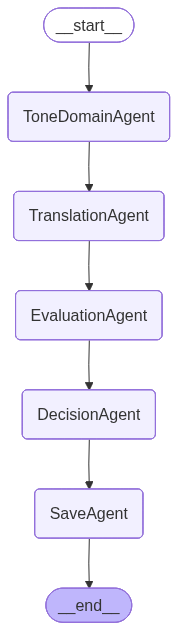

In [17]:
# ✅ Visualize as Mermaid PNG
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization failed. Ensure Mermaid & pygraphviz dependencies are installed.")
    print(f"Error: {e}")


In [14]:
# -------------------------
# Run the graph once over full dataframe
# -------------------------
initial_state = {"df": df_input.copy()}
final_state = app.invoke(initial_state)

2025-11-04 17:25:36,950 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:25:46,007 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:03,216 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:07,836 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:17,570 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:22,801 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:32,683 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:40,617 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-11-04 17:26:46,593 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "

In [15]:
# -------------------------
# Final summary dashboard
# -------------------------
out_df = final_state.get("df_final", pd.DataFrame())
matrix_df = final_state.get("matrix_df", pd.DataFrame())

total_openai_tokens = int(out_df.get("OpenAI_Tokens", pd.Series(dtype=int)).sum())
total_gemini_tokens = int(out_df.get("Gemini_Tokens", pd.Series(dtype=int)).sum())

yes_counts = out_df[out_df["Classification"] == "Yes"]["Best"].value_counts()
final_best_model = yes_counts.idxmax() if not yes_counts.empty else None
final_best_count = int(yes_counts.max()) if not yes_counts.empty else 0
avg_accuracy = round(out_df["Accuracy(%)"].mean(), 2) if "Accuracy(%)" in out_df.columns else 0.0

summary_table = [
    ["Total OpenAI Tokens", total_openai_tokens],
    ["Total Gemini Tokens", total_gemini_tokens],
    ["Final Best Model (by Yes count)", final_best_model],
    ["Final Best Model Yes-Count", final_best_count],
    ["Average Accuracy (%)", avg_accuracy],
    ["Rows processed", len(out_df)]
]

print("\n=== Final Evaluation Summary ===")
print(tabulate(summary_table, headers=["Metric", "Value"], tablefmt="github"))

logger.info(f"Per-row CSV saved: {OUT_PER_ROW}")
logger.info(f"Decision matrix saved: {OUT_MATRIX}")
print("\n✅ Pipeline finished. Check the CSV files in ./data/")

# End of script

2025-11-04 18:31:36,466 | INFO | Per-row CSV saved: data/final_langgraph_agent_results_token.csv
2025-11-04 18:31:36,468 | INFO | Decision matrix saved: data/decision_matrix_summary.csv



=== 📊 Final Evaluation Summary ===
| Metric                          | Value   |
|---------------------------------|---------|
| Total OpenAI Tokens             | 23409   |
| Total Gemini Tokens             | 29216   |
| Final Best Model (by Yes count) | OpenAI  |
| Final Best Model Yes-Count      | 62      |
| Average Accuracy (%)            | 45.97   |
| Rows processed                  | 673     |

✅ Pipeline finished. Check the CSV files in ./data/
